<a href="https://colab.research.google.com/github/brahmani2008/Nasscom-lab/blob/main/U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [2]:
rolls = np.random.randint(1, 7, size=100_000)
p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [7]:
# 1. P(both heads) -> heads == 2
p_both_heads = np.mean(heads == 2)
print("P(both heads):", p_both_heads)

# 2. P(at least one head) -> heads >= 1
p_at_least_one = np.mean(heads >= 1)
print("P(at least one head):", p_at_least_one)

# 3. Do P(0) + P(1) + P(2) sum to 1?
p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)

print("P(0) + P(1) + P(2):", p_0 + p_1 + p_2)
print("Sums to 1:", np.isclose(p_0 + p_1 + p_2, 1))

P(both heads): 0.24905
P(at least one head): 0.74948
P(0) + P(1) + P(2): 1.0
Sums to 1: True


In [8]:
rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.331  (true 1/3)


In [9]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.501
P(A | B)  = 0.669
Independent? False


In [10]:
# 1. P(odd | roll < 4)
condition = rolls < 4
p_odd_given_less4 = np.mean(rolls[condition] % 2 == 1)
print("P(odd | roll < 4):", p_odd_given_less4)

# 2. P(roll < 4)
p_less4 = np.mean(rolls < 4)
print("P(roll < 4):", p_less4)

# 3. Compare P(odd | <4) with P(odd) overall
p_odd = np.mean(rolls % 2 == 1)
print("P(odd):", p_odd)

print("Independent?", np.isclose(p_odd_given_less4, p_odd))

P(odd | roll < 4): 0.6688788194722913
P(roll < 4): 0.49876
P(odd): 0.50117
Independent? False


In [11]:
# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [12]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.495


In [13]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print("P(free):", p_free)

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | free):", p_spam_given_free)

P(free): 0.16
P(spam | free): 0.75


In [14]:
# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


Bernoulli(0.3) mean ~ 0.299 (true 0.3)
Poisson(4) mean ~ 3.978 (true 4)


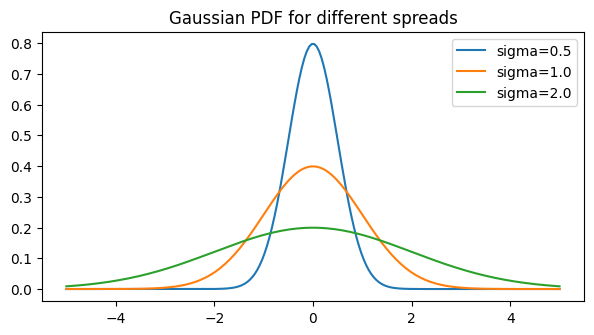

In [15]:
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()


Sample mean: 2.00754


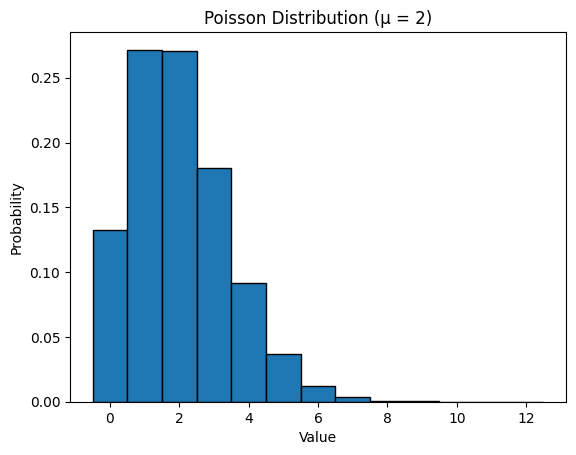

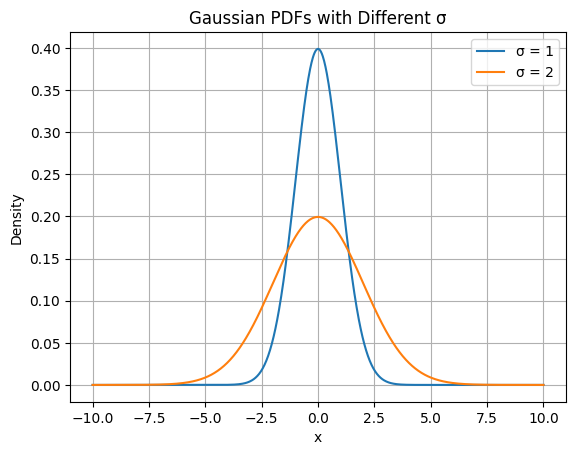

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Poisson(mu=2) samples + mean
samples = np.random.poisson(lam=2, size=100_000)
print("Sample mean:", samples.mean())

# 2. Histogram of the samples
plt.hist(samples, bins=np.arange(-0.5, samples.max() + 1.5, 1),
         density=True, edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.title("Poisson Distribution (μ = 2)")
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-10, 10, 1000)

mu = 0
sigma1 = 1
sigma2 = 2

pdf1 = norm.pdf(x, mu, sigma1)
pdf2 = norm.pdf(x, mu, sigma2)

plt.plot(x, pdf1, label="σ = 1")
plt.plot(x, pdf2, label="σ = 2")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian PDFs with Different σ")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')



Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [18]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [19]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')


0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [20]:
import numpy as np
from scipy.stats import entropy

# 1. Entropy of a fair 4-sided and 6-sided die (base=2)
p4 = np.ones(4) / 4
p6 = np.ones(6) / 6

H4 = entropy(p4, base=2)
H6 = entropy(p6, base=2)

print("Entropy of 4-sided die:", H4)
print("Entropy of 6-sided die:", H6)

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

D_PQ = entropy(P, Q)
print("KL divergence D(P || Q):", D_PQ)

# 3. Most / least informative iris feature (from 5C)
# Based on typical Iris dataset feature separability:
# Most informative: petal length
# Least informative: sepal width

print("Most informative: petal length")
print("Least informative: sepal width")

Entropy of 4-sided die: 2.0
Entropy of 6-sided die: 2.584962500721156
KL divergence D(P || Q): 0.08228287850505175
Most informative: petal length
Least informative: sepal width
